# Data Preprocessing

This notebook prepares two analysis-ready datasets from the original `train.csv` file.
The goal of these analysis is to extract the main semantic topics from civic complaints stored in the `text_en` column. Each created dataset will be saved in data folder and used for its respective pipeline.

For Pipeline A we obtain 'df_sbert'
For Pipeline B we obtain 'df_tfidf'

## Common Steps (applied to both pipelines)

1. Drop all columns except for the complaint column 'text_en' ( the other columns were analysed and discarded previously)
2. Check for null values and remove duplicates in `text_en`
3. Filter complaints by length: retain only texts between 10 and 100 words to remove uninformative entries and outliers

In [1]:
import pandas as pd
df = df = pd.read_csv("data/train.csv")
df.head()

,original_id,Complain_date,complaint_title,text_en,location_address,category_primary,category_secondary,resolution_status,comment_count,Hindi,Hinglish
0,BBMP_008791,03-08-2020 13:41,Streetlights not working,Diagonal road connecting bendre circle and BBM...,Opposite govt nature cure hospital,Electricity,Streetlights & Public Lighting,Open,0,बेंद्रे सर्कल और बीबीएमपी योग हॉल को जोड़ने वा...,Bendre circle aur BBMP yoga hall ko jodnewali ...
1,BBMP_004679,09-06-2019 07:21,This is in middle of the road,This is in middle of the road,NaN,Road & Transportation,Road Damage & Potholes,Resolved,2,यह सड़क के बीच में है।,Yeh sadak ke beech mein hai.
2,BBMP_006119,10/31/2019 17:36,There is big hole on the road where people wil...,There is big hole on the road where people wil...,NaN,Road & Transportation,Road Damage & Potholes,Resolved,1,सड़क पर एक बड़ा गड्ढा है जहाँ लोग बहुत तेज़ी स...,Sadak par ek bada gaddha hai jahan log bahut t...
3,BBMP_000306,1/22/2019 19:00,A lot of garbage is accumulated on harlur road...,A lot of garbage is accumulated on harlur road...,NaN,Waste Management,Garbage Dumping & Black Spots,Re-opened,4,हरलूर रोड पर जलाशय के पास बहुत कचरा जमा हो गया...,Harlur Road par jalashay ke paas bahut kachra ...
4,BBMP_008274,2/15/2020 16:35,Road clearing material is just left. This plac...,Road clearing material is just left. This plac...,NaN,Waste Management,Garbage Dumping & Black Spots,Resolved,1,सड़क साफ करने वाली सामग्री बस छोड़ दी गई है। इ...,Sadak saaf karne wali samagri bas chhod di gay...


In [2]:
df = df.drop(columns=['location_address', 'Complain_date','resolution_status','Hindi','Hinglish','complaint_title','category_primary', 'category_secondary', 'comment_count','original_id'])

In [3]:
df.head()

,text_en
0,Diagonal road connecting bendre circle and BBM...
1,This is in middle of the road
2,There is big hole on the road where people wil...
3,A lot of garbage is accumulated on harlur road...
4,Road clearing material is just left. This plac...


In [4]:
df.shape

(8000, 1)

### Outliers Analysis
Since the most of the complains have a length between 10-100 according to the graph and to the percetniles shown 
in the latter 2 cells, outlieres are conisdered to be any point outside of this range and are cutted out form the data.
Moreover, duplicates are also left out and cut off in the next cell, and the cleaned complaints are saved in df_clean

In [5]:
df['text_len'] = df['text_en'].str.split().str.len()
df['text_len'].describe()

count    8000.000000
mean       39.138625
std        39.084835
min         1.000000
25%        13.000000
50%        28.000000
75%        52.000000
max       527.000000
Name: text_len, dtype: float64

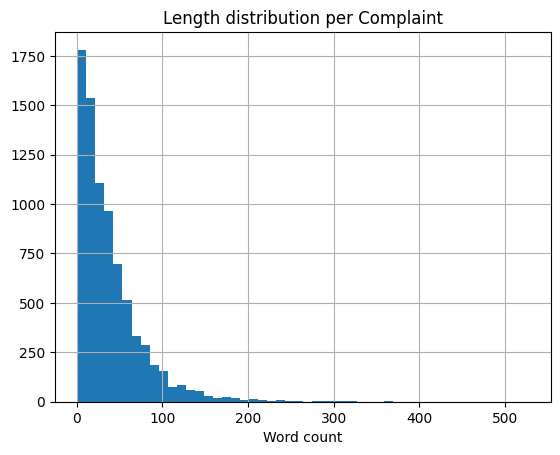

In [6]:
import matplotlib.pyplot as plt
df['text_len'].hist(bins=50)
plt.xlabel('Word count')
plt.title('Length distribution per Complaint')
plt.show()

In [7]:
df_clean = df[(df['text_len'] >= 10) & (df['text_len'] <= 100)].copy()
print(f"After length filter: {len(df_clean)} / {len(df)} rows kept")

df_clean = df_clean.drop_duplicates(subset='text_en')
print(f"After dropping duplicates: {len(df_clean)} rows remaining")

After length filter: 6015 / 8000 rows kept
After dropping duplicates: 5943 rows remaining


## Pipeline A — `df_sbert`
Minimal preprocessing is applied since SBERT was pre-trained on natural English sentences and benefits from preserved grammatical structure.

1. Convert text to lowercase
2. Remove non-UTF-8 characters and extra whitespace


In [8]:
import re


def preprocess_sbert(text):
    # convert text to lowercase
    text = text.lower()
    # remove any corrupted or non-standard characters from the raw text
    text = text.encode('utf-8', errors='ignore').decode('utf-8')
    #text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['text_sbert'] = df_clean['text_en'].apply(preprocess_sbert)

df_sbert = df_clean[[ 'text_en', 'text_sbert']].reset_index(drop=True)
print(f"\ndf_sbert ready: {df_sbert.shape[0]} rows, {df_sbert.shape[1]} columns")

df_sbert.to_csv('data/df_sbert.csv', index=False)
print("df_sbert saved to data/df_sbert.csv")


df_sbert ready: 5943 rows, 2 columns
df_sbert saved to data/df_sbert.csv


## Pipeline B — `df_tfidf`
Extended preprocessing is applied since TF-IDF relies purely on word frequency counts and is sensitive to noise and vocabulary size.

1. Convert text to lowercase
2. Remove special characters and digits
3. Remove stop words
4. Lemmatize tokens to reduce vocabulary size

In [9]:
import warnings
warnings.filterwarnings('ignore')
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_tfidf(text):
    # lowercase
    text = text.lower()
    # remove special characters, digits and extra whitespace
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # tokenize, remove stop words and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# apply to df_clean
print("Preprocessing for Pipeline B (TF-IDF + LSA)...")
df_clean['text_tfidf'] = df_clean['text_en'].apply(preprocess_tfidf)
print(f"Done — sample:\n{df_clean['text_tfidf'].iloc[0]}")

# create pipeline B dataframe
df_tfidf = df_clean[['text_en', 'text_tfidf']].reset_index(drop=True)
print(f"\ndf_tfidf ready: {df_tfidf.shape[0]} rows, {df_tfidf.shape[1]} columns")

# drop NaN values in text_tfidf before vectorizing
df_tfidf = df_tfidf.dropna(subset=['text_tfidf'])
df_tfidf = df_tfidf[df_tfidf['text_tfidf'].str.strip() != '']

# save
df_tfidf.to_csv('data/df_tfidf.csv', index=False)
print("df_tfidf saved to data/df_tfidf.csv")

Preprocessing for Pipeline B (TF-IDF + LSA)...
Done — sample:
diagonal road connecting bendre circle bbmp yoga hall next cosmo club garage run opposite govt nature cure hospital unsafe early morning due street light working

df_tfidf ready: 5943 rows, 2 columns
df_tfidf saved to data/df_tfidf.csv


In [10]:
df_tfidf.head()

,text_en,text_tfidf
0,Diagonal road connecting bendre circle and BBM...,diagonal road connecting bendre circle bbmp yo...
1,There is big hole on the road where people wil...,big hole road people coming fast control vehic...
2,A lot of garbage is accumulated on harlur road...,lot garbage accumulated harlur road near water...
3,Road clearing material is just left. This plac...,road clearing material left place used plant tree
4,There is a water supply vendor R N Water suppl...,water supply vendor water supply come main lic...
